In [ ]:
import numpy as np

In [ ]:
import pandas as pd

In [ ]:
weather=pd.read_csv("/content/weather.csv")

In [ ]:
weather

,STATION,NAME,DATE,ACMH,ACSH,AWND,FMTM,PGTM,PRCP,SNOW,...,WT11,WT13,WT14,WT15,WT16,WT17,WT18,WT21,WT22,WV01
0,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",1970-01-01,80.0,90.0,NaN,NaN,NaN,0.00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",1970-01-02,30.0,20.0,NaN,NaN,NaN,0.00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",1970-01-03,80.0,100.0,NaN,NaN,NaN,0.02,0.0,...,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN
3,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",1970-01-04,10.0,20.0,NaN,NaN,NaN,0.00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
4,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",1970-01-05,30.0,10.0,NaN,NaN,NaN,0.00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19282,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2022-10-17,NaN,NaN,9.62,NaN,NaN,0.08,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19283,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2022-10-18,NaN,NaN,12.08,NaN,NaN,0.00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19284,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2022-10-19,NaN,NaN,14.99,NaN,NaN,0.00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19285,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2022-10-20,NaN,NaN,16.78,NaN,10.0,0.00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
null_pct=weather.apply(pd.isnull).sum()/weather.shape[0]
null_pct

,0
STATION,0.000000
NAME,0.000000
DATE,0.000000
ACMH,0.501478
ACSH,0.501426
AWND,0.265256
FMTM,0.475087
PGTM,0.363872
PRCP,0.000000
SNOW,0.000000


In [ ]:
valid_columns=weather.columns[null_pct<.05]
valid_columns

Index(['STATION', 'NAME', 'DATE', 'PRCP', 'SNOW', 'SNWD', 'TMAX', 'TMIN'], dtype='object')

In [ ]:
weather=weather[valid_columns].copy()

In [ ]:
weather.columns=weather.columns.str.lower()

In [ ]:
weather

,station,name,date,prcp,snow,snwd,tmax,tmin
0,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",1970-01-01,0.00,0.0,0.0,28,22
1,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",1970-01-02,0.00,0.0,0.0,31,22
2,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",1970-01-03,0.02,0.0,0.0,38,25
3,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",1970-01-04,0.00,0.0,0.0,31,23
4,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",1970-01-05,0.00,0.0,0.0,35,21
...,...,...,...,...,...,...,...,...
19282,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2022-10-17,0.08,0.0,0.0,67,54
19283,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2022-10-18,0.00,0.0,0.0,58,48
19284,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2022-10-19,0.00,0.0,0.0,56,43
19285,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2022-10-20,0.00,0.0,0.0,61,44


In [ ]:
weather=weather.ffill()

In [ ]:
weather.apply(pd.isnull).sum()

,0
station,0
name,0
date,0
prcp,0
snow,0
snwd,0
tmax,0
tmin,0


In [ ]:
weather.apply(lambda x: (x==9999).sum())

,0
station,0
name,0
date,0
prcp,0
snow,0
snwd,0
tmax,0
tmin,0


In [ ]:
weather.dtypes

,0
station,object
name,object
date,object
prcp,float64
snow,float64
snwd,float64
tmax,int64
tmin,int64


In [ ]:
weather.index

RangeIndex(start=0, stop=19287, step=1)

In [ ]:
weather.index=pd.to_datetime(weather.index)

In [ ]:
weather.index.year.value_counts().sort_index()

,count
1970,19287


<Axes: >

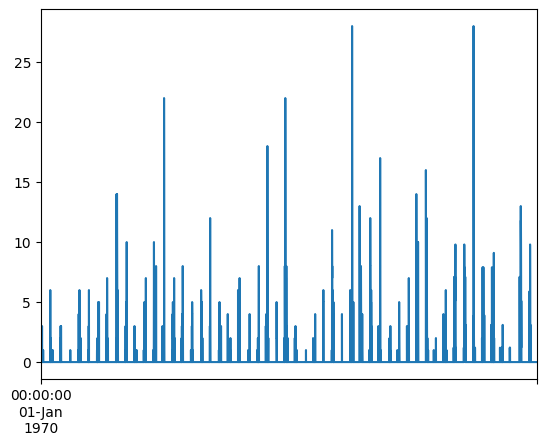

In [ ]:
weather["snwd"].plot()

In [ ]:
weather["target"]=weather.shift(-1)["tmax"]

In [ ]:
weather

,station,name,date,prcp,snow,snwd,tmax,tmin,target
1970-01-01 00:00:00.000000000,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",1970-01-01,0.00,0.0,0.0,28,22,31.0
1970-01-01 00:00:00.000000001,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",1970-01-02,0.00,0.0,0.0,31,22,38.0
1970-01-01 00:00:00.000000002,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",1970-01-03,0.02,0.0,0.0,38,25,31.0
1970-01-01 00:00:00.000000003,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",1970-01-04,0.00,0.0,0.0,31,23,35.0
1970-01-01 00:00:00.000000004,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",1970-01-05,0.00,0.0,0.0,35,21,36.0
...,...,...,...,...,...,...,...,...,...
1970-01-01 00:00:00.000019282,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2022-10-17,0.08,0.0,0.0,67,54,58.0
1970-01-01 00:00:00.000019283,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2022-10-18,0.00,0.0,0.0,58,48,56.0
1970-01-01 00:00:00.000019284,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2022-10-19,0.00,0.0,0.0,56,43,61.0
1970-01-01 00:00:00.000019285,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2022-10-20,0.00,0.0,0.0,61,44,64.0


In [ ]:
weather=weather.ffill()

In [ ]:
weather

,station,name,date,prcp,snow,snwd,tmax,tmin,target
1970-01-01 00:00:00.000000000,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",1970-01-01,0.00,0.0,0.0,28,22,31.0
1970-01-01 00:00:00.000000001,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",1970-01-02,0.00,0.0,0.0,31,22,38.0
1970-01-01 00:00:00.000000002,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",1970-01-03,0.02,0.0,0.0,38,25,31.0
1970-01-01 00:00:00.000000003,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",1970-01-04,0.00,0.0,0.0,31,23,35.0
1970-01-01 00:00:00.000000004,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",1970-01-05,0.00,0.0,0.0,35,21,36.0
...,...,...,...,...,...,...,...,...,...
1970-01-01 00:00:00.000019282,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2022-10-17,0.08,0.0,0.0,67,54,58.0
1970-01-01 00:00:00.000019283,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2022-10-18,0.00,0.0,0.0,58,48,56.0
1970-01-01 00:00:00.000019284,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2022-10-19,0.00,0.0,0.0,56,43,61.0
1970-01-01 00:00:00.000019285,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2022-10-20,0.00,0.0,0.0,61,44,64.0


In [ ]:
weather=weather.ffill()

In [ ]:
from sklearn.linear_model import Ridge
rr=Ridge(alpha=.1)

In [ ]:
predictors=weather.columns[~weather.columns.isin(["target","name","station"])]

In [ ]:
def backtest(weather, model, predictors, start=3650, step=90):
  all_predictions = []

  for i in range(start, weather.shape[0], step):
    train = weather.iloc[:i, :].copy() # Create a copy to avoid SettingWithCopyWarning
    test = weather.iloc[i:(i+step), :].copy() # Create a copy to avoid SettingWithCopyWarning

    # Reset index to avoid DatetimeIndex being included in predictors
    train = train.reset_index(drop=True)
    test = test.reset_index(drop=True)

    model.fit(train[predictors], train["target"])

    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index)
    combined = pd.concat([test["target"], preds], axis=1)
    combined.columns = ["actual", "prediction"]
    combined["diff"] = (combined["prediction"] - combined["actual"]).abs()

    all_predictions.append(combined)
  return pd.concat(all_predictions)

In [ ]:
predictors = [p for p in predictors if p != weather.index.name]

In [ ]:
print(weather[predictors].dtypes)

date     object
prcp    float64
snow    float64
snwd    float64
tmax      int64
tmin      int64
dtype: object


In [ ]:
weather["date"] = pd.to_datetime(weather["date"]).astype(int) / 10**9

In [ ]:
predictors = [col for col in predictors if weather[col].dtype in [np.float64, np.int64]]

In [ ]:
# Ensure predictors include only numeric columns
predictors = [col for col in predictors if weather[col].dtype in [np.float64, np.int64]]

# Run backtest
predictions = backtest(weather, rr, predictors)

# Calculate the mean absolute error
mae = mean_absolute_error(predictions["actual"], predictions["prediction"])
print(f"Mean Absolute Error: {mae}")

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.04309e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=9.83414e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=9.63343e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=9.18689e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarnin

Mean Absolute Error: 5.138576665527081


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.55395e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.49644e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.45327e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.39878e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarnin

In [ ]:
print(weather[predictors].head())

                                   date  prcp  snow  snwd  tmax  tmin
1970-01-01 00:00:00.000000000       0.0  0.00   0.0   0.0    28    22
1970-01-01 00:00:00.000000001   86400.0  0.00   0.0   0.0    31    22
1970-01-01 00:00:00.000000002  172800.0  0.02   0.0   0.0    38    25
1970-01-01 00:00:00.000000003  259200.0  0.00   0.0   0.0    31    23
1970-01-01 00:00:00.000000004  345600.0  0.00   0.0   0.0    35    21


In [ ]:
predictions.sort_values("diff",ascending=False)

,actual,prediction,diff
48,78.0,49.955413,28.044587
46,84.0,56.815589,27.184411
13,53.0,26.108242,26.891758
35,85.0,58.169167,26.830833
1,80.0,53.180433,26.819567
...,...,...,...
60,51.0,51.001370,0.001370
68,83.0,82.998651,0.001349
62,22.0,21.998736,0.001264
0,57.0,56.998768,0.001232


In [ ]:
pd.Series(rr.coef_,index=predictors)

,0
date,3.428142e-10
prcp,-1.243354e+00
snow,-4.107550e-01
snwd,4.676900e-02
tmax,4.456352e-01
tmin,5.186696e-01


In [ ]:
def pct_diff(old,new):
  return(new-old)/old

def compute_rolling(weather, horizon, col):
  label=f"rolling_{horizon}_{col}"
  weather[label]=weather[col].rolling(horizon).mean()
  weather[f"{label}_pct"]=pct_diff(weather[label],weather[col])
  return weather

rolling_horizons=[3,14]
for horizon in rolling_horizons:
  for col in["tmax","tmin","prcp"]:
    weather=compute_rolling(weather, horizon, col)

In [ ]:
def expand_mean(df):
  return df.expanding(1).mean()

for col in ["tmax", "tmin", "prcp"]:
  weather[f"month_avg_col{col}"]=weather[col].groupby(weather.index.month,group_keys=False).apply(expand_mean)
  weather[f"day_avg_{col}"]=weather[col].groupby(weather.index.day_of_year,group_keys=False).apply(expand_mean)

In [ ]:
weather=weather.iloc[14:,:]
weather=weather.fillna(0)

In [ ]:
predictors=weather.columns[~weather.columns.isin(["target", "name", "station"])]

In [ ]:
predicitons=backtest(weather,rr,predictors)
mean_absolute_error(predictions["actual"],predictions["prediction"])

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=3.25087e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=3.02326e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=2.81892e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=2.6292e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning

5.138576665527081

In [ ]:
mean_squared_error(predictions["actual"],predictions["prediction"])

43.05481283954144

In [ ]:
predictions.sort_values("diff",ascending=False)

,actual,prediction,diff
48,78.0,49.955413,28.044587
46,84.0,56.815589,27.184411
13,53.0,26.108242,26.891758
35,85.0,58.169167,26.830833
1,80.0,53.180433,26.819567
...,...,...,...
60,51.0,51.001370,0.001370
68,83.0,82.998651,0.001349
62,22.0,21.998736,0.001264
0,57.0,56.998768,0.001232


In [ ]:
weather.loc["1990-03-07":"1990-03-17"]

,station,name,date,prcp,snow,snwd,tmax,tmin,target,rolling_3_tmax,...,rolling_14_tmin,rolling_14_tmin_pct,rolling_14_prcp,rolling_14_prcp_pct,month_avg_coltmax,day_avg_tmax,month_avg_coltmin,day_avg_tmin,month_avg_colprcp,day_avg_prcp


<Axes: xlabel='diff'>

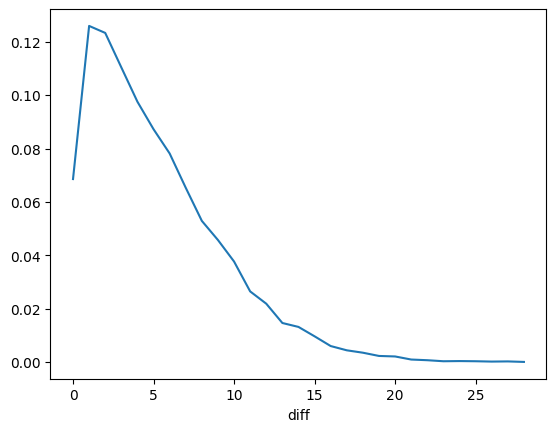

In [ ]:
(predictions["diff"].round().value_counts().sort_index()/predictions.shape[0]).plot()

In [ ]:
predictions

,actual,prediction,diff
0,43.0,50.155330,7.155330
1,42.0,43.598976,1.598976
2,41.0,41.503942,0.503942
3,36.0,43.887371,7.887371
4,30.0,40.130055,10.130055
...,...,...,...
62,58.0,67.831376,9.831376
63,56.0,60.808140,4.808140
64,61.0,57.323551,3.676449
65,64.0,60.070426,3.929574
